# Avocado ML Project

#### Group Members
+ Esther Akinboye
+ Mercy Inameti
+ Victoria Eghonghon Eronlan
+ Khadijat Oyedeji
+ Nkiru Johanna Ezedinma
+ Sarah David
+ Adaeze Chime

In [1]:
# Import libraries
import pandas as pd
import numpy as np
from plotnine import *

In [3]:
# Load dataset
avocado_raw = pd.read_csv('avocado.csv')

## Tasks:  Data Preparation
+ Convert Date column to datetime format
+ Handle missing values
+ Extract features such as month and year
+ Aggregate data if necessary

In [3]:
avocado_raw.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [4]:
avocado_raw.shape

(18249, 14)

### Data Cleaning

In [5]:
import janitor
avocado = avocado_raw.clean_names().drop('unnamed_0', axis=1)
avocado.head()

,date,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region
0,12/27/2015,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,12/20/2015,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,12/13/2015,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,12/6/2015,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,11/29/2015,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [6]:
#converting from wide to long format
avocado_long = ( avocado.pivot_longer(index = ['date','averageprice','total_volume','total_bags', 'small_bags', 'large_bags', 'xlarge_bags','type','year','region'],
                names_to = 'plu_code',
                values_to = 'plu_volume',
                dropna = True
                                    )
.pivot_longer(index = ['date','averageprice','total_volume','total_bags','type','year','region','plu_code', 'plu_volume'],
                                          names_to = 'bag_type',
                                          values_to = 'bag_volume',
                                          dropna = True))
avocado_long = avocado_long.rename(columns={'averageprice': 'average_price'})

avocado_long['bag_type'] = avocado_long['bag_type'].str.replace('_', ' ')
avocado_long.head()

,date,average_price,total_volume,total_bags,type,year,region,plu_code,plu_volume,bag_type,bag_volume
0,12/27/2015,1.33,64236.62,8696.87,conventional,2015,Albany,4046,1036.74,small bags,8603.62
1,12/20/2015,1.35,54876.98,9505.56,conventional,2015,Albany,4046,674.28,small bags,9408.07
2,12/13/2015,0.93,118220.22,8145.35,conventional,2015,Albany,4046,794.70,small bags,8042.21
3,12/6/2015,1.08,78992.15,5811.16,conventional,2015,Albany,4046,1132.00,small bags,5677.40
4,11/29/2015,1.28,51039.60,6183.95,conventional,2015,Albany,4046,941.48,small bags,5986.26


In [7]:
#Checking for missing values
avocado_long.isna().sum()
#there are no missing values

date             0
average_price    0
total_volume     0
total_bags       0
type             0
year             0
region           0
plu_code         0
plu_volume       0
bag_type         0
bag_volume       0
dtype: int64

In [8]:
avocado_long.duplicated().sum()
#there are no duplicates

np.int64(0)

In [9]:
#SUMMARY STATISTICS
avocado_long.describe()

,average_price,total_volume,total_bags,year,plu_volume,bag_volume
count,164241.000000,1.642410e+05,1.642410e+05,164241.000000,1.642410e+05,1.642410e+05
mean,1.405978,8.506440e+05,2.396392e+05,2016.147899,2.036676e+05,7.987973e+04
std,0.402667,3.453461e+06,9.862184e+05,0.939916,1.018259e+06,4.595649e+05
min,0.440000,8.456000e+01,0.000000e+00,2015.000000,0.000000e+00,0.000000e+00
25%,1.100000,1.083858e+04,5.088640e+03,2015.000000,2.350000e+02,0.000000e+00
50%,1.370000,1.073768e+05,3.974383e+04,2016.000000,5.005720e+03,1.698160e+03
75%,1.660000,4.329623e+05,1.107834e+05,2017.000000,6.731604e+04,2.724524e+04
max,3.250000,6.250565e+07,1.937313e+07,2018.000000,2.274362e+07,1.338459e+07


In [10]:
avocado_long.skew(numeric_only = True)

average_price     0.580260
total_volume      9.007029
total_bags        9.755359
year              0.215323
plu_volume       10.716275
bag_volume       14.672502
dtype: float64

In [11]:
avocado_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164241 entries, 0 to 164240
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   date           164241 non-null  object 
 1   average_price  164241 non-null  float64
 2   total_volume   164241 non-null  float64
 3   total_bags     164241 non-null  float64
 4   type           164241 non-null  object 
 5   year           164241 non-null  int64  
 6   region         164241 non-null  object 
 7   plu_code       164241 non-null  object 
 8   plu_volume     164241 non-null  float64
 9   bag_type       164241 non-null  object 
 10  bag_volume     164241 non-null  float64
dtypes: float64(5), int64(1), object(5)
memory usage: 13.8+ MB


In [12]:
#converting date column to date time format
avocado_long['date'] = pd.to_datetime(avocado_long['date'])
avocado_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164241 entries, 0 to 164240
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   date           164241 non-null  datetime64[ns]
 1   average_price  164241 non-null  float64       
 2   total_volume   164241 non-null  float64       
 3   total_bags     164241 non-null  float64       
 4   type           164241 non-null  object        
 5   year           164241 non-null  int64         
 6   region         164241 non-null  object        
 7   plu_code       164241 non-null  object        
 8   plu_volume     164241 non-null  float64       
 9   bag_type       164241 non-null  object        
 10  bag_volume     164241 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(4)
memory usage: 13.8+ MB


In [13]:
avocado_long_str = avocado_long['date'].astype(str)

# extracting the month and day column
avocado_long_ds = (avocado_long_str.str.split("-", expand=True)
                   .rename(columns={0: "year",
                                    1: "month",
                                    2: "day"})
                   [['month', 'day']]) 

avocado_long_ds

,month,day
0,12,27
1,12,20
2,12,13
3,12,06
4,11,29
...,...,...
164236,02,04
164237,01,28
164238,01,21
164239,01,14


In [14]:
#Adding it back to the main table
avocado = pd.concat([avocado_long, avocado_long_ds], axis = 1)
avocado.head()

,date,average_price,total_volume,total_bags,type,year,region,plu_code,plu_volume,bag_type,bag_volume,month,day
0,2015-12-27,1.33,64236.62,8696.87,conventional,2015,Albany,4046,1036.74,small bags,8603.62,12,27
1,2015-12-20,1.35,54876.98,9505.56,conventional,2015,Albany,4046,674.28,small bags,9408.07,12,20
2,2015-12-13,0.93,118220.22,8145.35,conventional,2015,Albany,4046,794.70,small bags,8042.21,12,13
3,2015-12-06,1.08,78992.15,5811.16,conventional,2015,Albany,4046,1132.00,small bags,5677.40,12,06
4,2015-11-29,1.28,51039.60,6183.95,conventional,2015,Albany,4046,941.48,small bags,5986.26,11,29


In [15]:
#Creating a season column
avocado['month'] = avocado['month'].astype(int)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

avocado['season'] = avocado['month'].apply(get_season)

In [16]:
# how many rows fall in each season
avocado['season'].value_counts()

season
Winter    45675
Spring    42768
Fall      37908
Summer    37890
Name: count, dtype: int64

In [17]:
#average price per season
avocado.groupby('season')['average_price'].mean().sort_values(ascending=False)

season
Fall      1.536147
Summer    1.462572
Spring    1.349266
Winter    1.304100
Name: average_price, dtype: float64

In [18]:
# unique type
print(avocado['type'].unique())

['conventional' 'organic']


In [19]:
avocado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164241 entries, 0 to 164240
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   date           164241 non-null  datetime64[ns]
 1   average_price  164241 non-null  float64       
 2   total_volume   164241 non-null  float64       
 3   total_bags     164241 non-null  float64       
 4   type           164241 non-null  object        
 5   year           164241 non-null  int64         
 6   region         164241 non-null  object        
 7   plu_code       164241 non-null  object        
 8   plu_volume     164241 non-null  float64       
 9   bag_type       164241 non-null  object        
 10  bag_volume     164241 non-null  float64       
 11  month          164241 non-null  int64         
 12  day            164241 non-null  object        
 13  season         164241 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(2), object(6

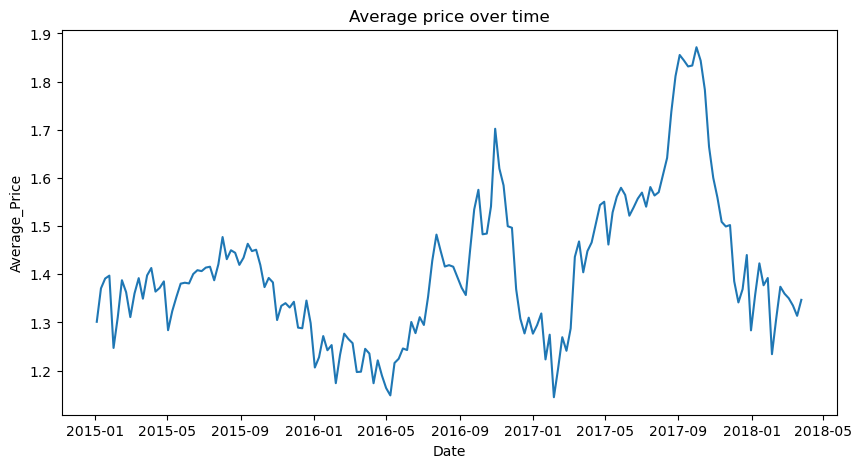

In [20]:
# Price Trend
price_trend = avocado.groupby('date')['average_price'].mean()

# Plot showing price trend over time
import matplotlib.pyplot as plt
plt.figure(figsize = (10,5))
plt.plot(price_trend.index,price_trend.values)
plt.title('Average price over time')
plt.xlabel('Date')
plt.ylabel('Average_Price')
plt.show()

# Interpretation
The time series line plot showed that price variations are not strongly driven by time alone supporting the use of a multivariate model like Linear Regression.

In [21]:
# Aggregating Dataset
avocado = (avocado.groupby(['date', 'day', 'type', 'year', 'month', 'season', 'region', 'bag_type', 'plu_code'], 
                          as_index=False)
               [['plu_volume', 'average_price', 'total_volume', 'total_bags', 'bag_volume']]
               .mean())

avocado.head()

,date,day,type,year,month,season,region,bag_type,plu_code,plu_volume,average_price,total_volume,total_bags,bag_volume
0,2015-01-04,04,conventional,2015,1,Winter,Albany,large bags,4046,2819.50,1.22,40873.28,9716.46,529.53
1,2015-01-04,04,conventional,2015,1,Winter,Albany,large bags,4225,28287.42,1.22,40873.28,9716.46,529.53
2,2015-01-04,04,conventional,2015,1,Winter,Albany,large bags,4770,49.90,1.22,40873.28,9716.46,529.53
3,2015-01-04,04,conventional,2015,1,Winter,Albany,small bags,4046,2819.50,1.22,40873.28,9716.46,9186.93
4,2015-01-04,04,conventional,2015,1,Winter,Albany,small bags,4225,28287.42,1.22,40873.28,9716.46,9186.93


# Part 1: Price Prediction
Objective: Predict avocado prices using Linear Regression

# Linear Regression

In [22]:
avocado.head()

,date,day,type,year,month,season,region,bag_type,plu_code,plu_volume,average_price,total_volume,total_bags,bag_volume
0,2015-01-04,04,conventional,2015,1,Winter,Albany,large bags,4046,2819.50,1.22,40873.28,9716.46,529.53
1,2015-01-04,04,conventional,2015,1,Winter,Albany,large bags,4225,28287.42,1.22,40873.28,9716.46,529.53
2,2015-01-04,04,conventional,2015,1,Winter,Albany,large bags,4770,49.90,1.22,40873.28,9716.46,529.53
3,2015-01-04,04,conventional,2015,1,Winter,Albany,small bags,4046,2819.50,1.22,40873.28,9716.46,9186.93
4,2015-01-04,04,conventional,2015,1,Winter,Albany,small bags,4225,28287.42,1.22,40873.28,9716.46,9186.93


### Correlation Check

In [23]:
#correlation 
#this should be below 0.5
avocado_corr = (avocado.corr(numeric_only = True))
avocado_corr

,year,month,plu_volume,average_price,total_volume,total_bags,bag_volume
year,1.000000,-0.177050,-0.003664,0.093197,0.017193,0.071552,0.051183
month,-0.177050,1.000000,-0.020575,0.162409,-0.024689,-0.022724,-0.016255
plu_volume,-0.003664,-0.020575,1.000000,-0.160737,0.819597,0.765891,0.547863
average_price,0.093197,0.162409,-0.160737,1.000000,-0.192752,-0.177088,-0.126676
total_volume,0.017193,-0.024689,0.819597,-0.192752,1.000000,0.963047,0.688894
total_bags,0.071552,-0.022724,0.765891,-0.177088,0.963047,1.000000,0.715328
bag_volume,0.051183,-0.016255,0.547863,-0.126676,0.688894,0.715328,1.000000


#### Or
Correlation using the heatmap method

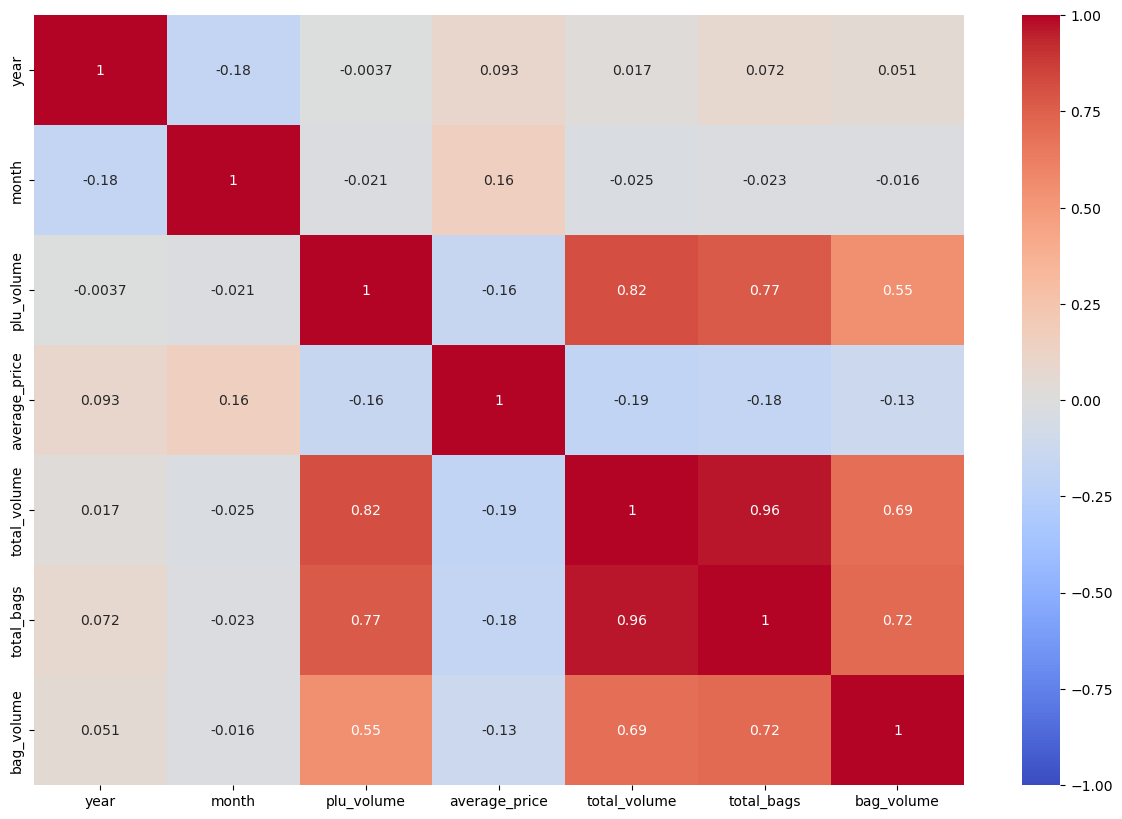

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
sns.heatmap(avocado.corr(numeric_only = True), vmin=-1, vmax=1, annot=True,  cmap='coolwarm')
plt.show()

### Interpretation
Total volume and bag sizes are strongly correlated with each other when more avocados are sold, more bags are used. Average price has a weak negative correlation with volume, confirming that higher supply slightly lowers price but the relationship is not strong enough to predict price reliably on its own.

In [25]:
from plotnine import *

### Interpretation
Prices are slightly higher in certain months but there is a lot of overlap, meaning month alone is not a strong predictor of price. The relationship is weak and scattered.

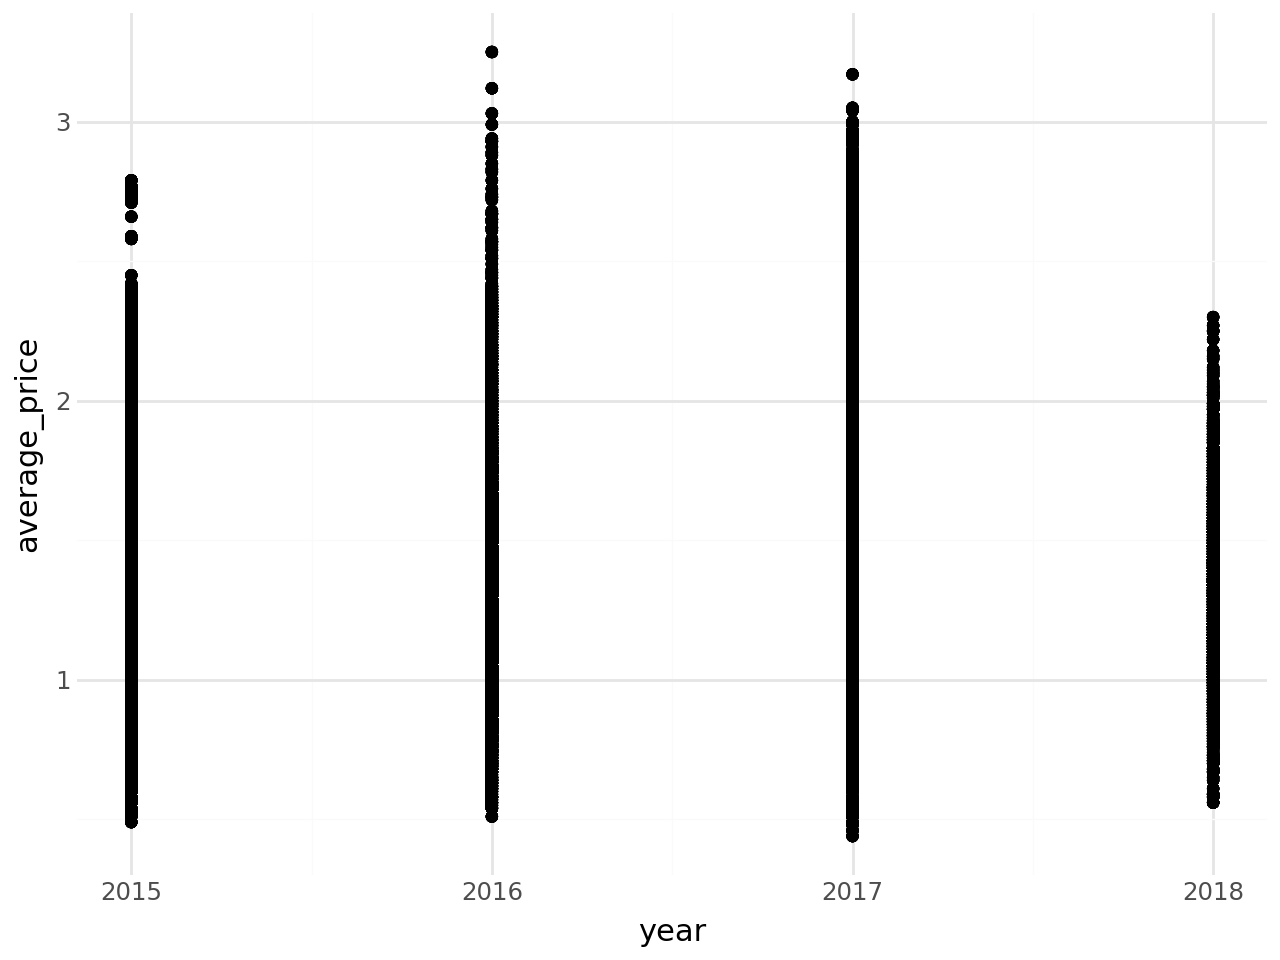

In [26]:
(ggplot(avocado, aes('year', 'average_price'))
+ geom_point()
+ theme_minimal()
)

### Interpretation
Prices show a general upward trend over the years, with 2017 being the most expensive year. However the spread within each year is wide, suggesting year captures a trend but not the full picture.

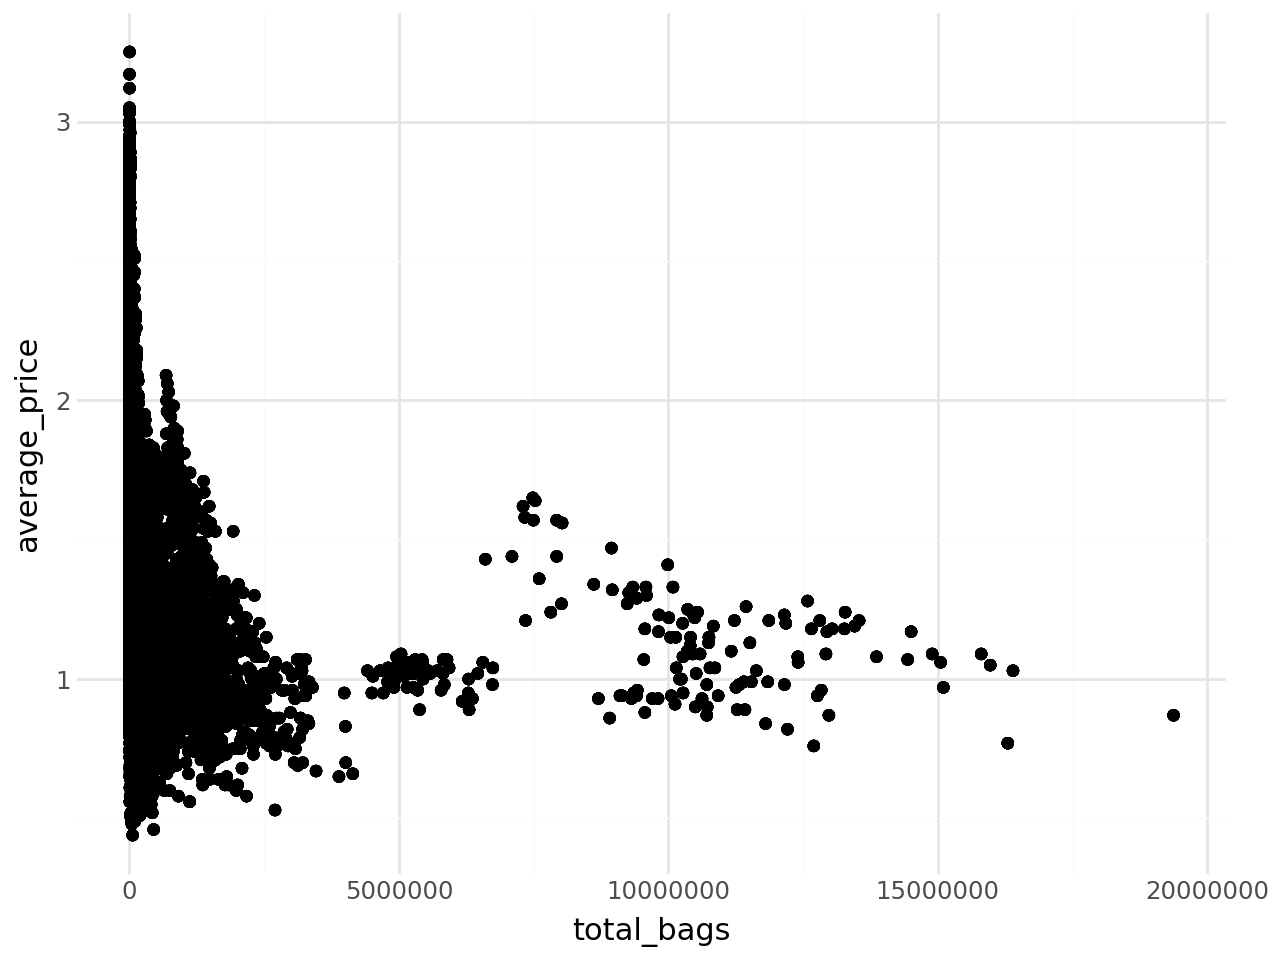

In [27]:
(ggplot(avocado, aes('total_bags', 'average_price'))
+ geom_point()
+ theme_minimal()
)

### Interpretation
There is no clear linear relationship between total bags and price. The data is heavily concentrated at lower bag volumes with a wide spread of prices, confirming that bag volume alone cannot reliably predict price.

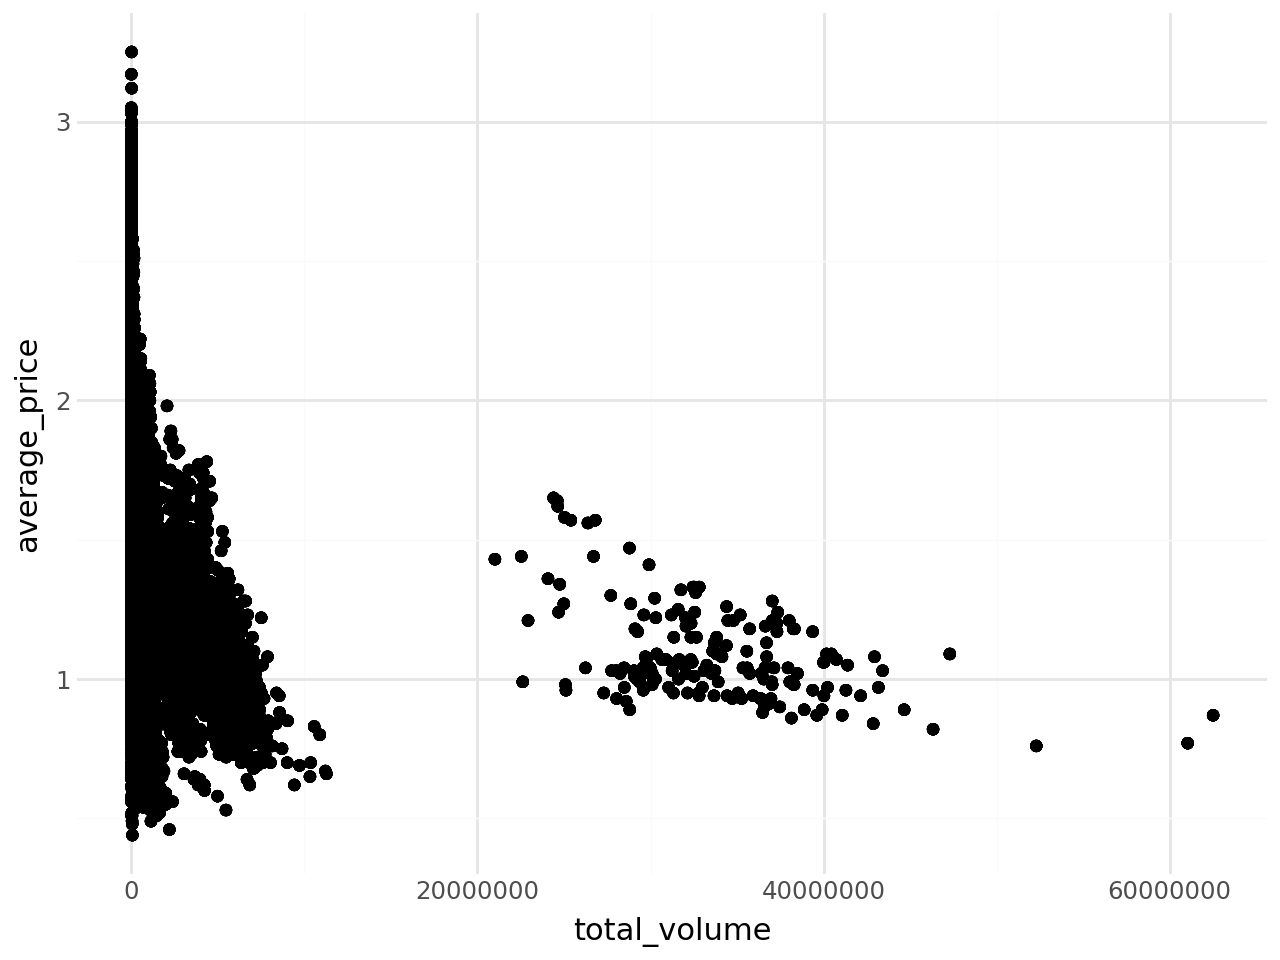

In [28]:
(ggplot(avocado, aes('total_volume', 'average_price'))
+ geom_point()
+ theme_minimal()
)

### Interpretation
As total volume increases, prices tend to cluster lower more supply pulls prices down slightly. However the relationship is weak and scattered at higher volumes, confirming that volume alone is a poor predictor of price.

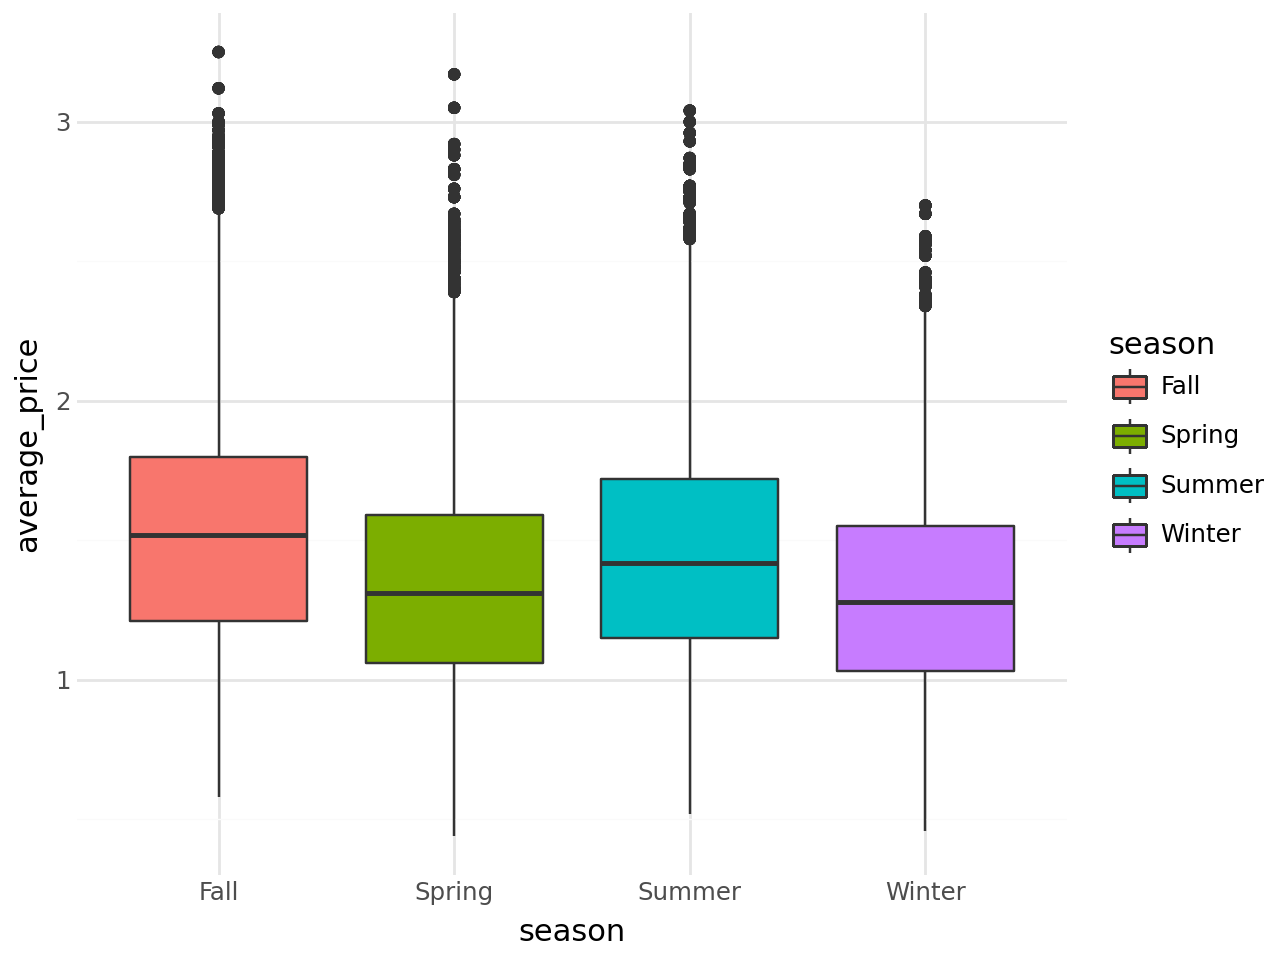

In [29]:
(ggplot(avocado, aes('season', 'average_price', fill='season'))
+ geom_boxplot()
+ theme_minimal())

# Interpretation
Fall has the highest median price and the widest spread, meaning prices are both high and variable in Fall. Winter has the lowest median price. All seasons show significant overlap in price ranges, which means season is a useful but not definitive predictor on its own.

#### Data Preprocessing

In [30]:
from sklearn.model_selection import train_test_split

## Model 1
Feature: total_volume

In [31]:
avocado.head()

,date,day,type,year,month,season,region,bag_type,plu_code,plu_volume,average_price,total_volume,total_bags,bag_volume
0,2015-01-04,04,conventional,2015,1,Winter,Albany,large bags,4046,2819.50,1.22,40873.28,9716.46,529.53
1,2015-01-04,04,conventional,2015,1,Winter,Albany,large bags,4225,28287.42,1.22,40873.28,9716.46,529.53
2,2015-01-04,04,conventional,2015,1,Winter,Albany,large bags,4770,49.90,1.22,40873.28,9716.46,529.53
3,2015-01-04,04,conventional,2015,1,Winter,Albany,small bags,4046,2819.50,1.22,40873.28,9716.46,9186.93
4,2015-01-04,04,conventional,2015,1,Winter,Albany,small bags,4225,28287.42,1.22,40873.28,9716.46,9186.93


In [32]:
#Feature Selection
independent_variables = avocado.drop('average_price', axis=1)
dependent_variables = avocado['average_price']

x_train, x_test, y_train, y_test = train_test_split(independent_variables, dependent_variables, test_size=0.2, random_state=42)

print('Training set size:', x_train.shape)
print('Test set size:', x_test.shape)

Training set size: (131392, 13)
Test set size: (32849, 13)


In [33]:
#Scaling total_volume on both training andd test data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train['total_volume'] = scaler.fit_transform(x_train[['total_volume']])
x_test['total_volume'] = scaler.transform(x_test[['total_volume']])
x_train.head()

,date,day,type,year,month,season,region,bag_type,plu_code,plu_volume,total_volume,total_bags,bag_volume
121140,2017-05-21,21,organic,2017,5,Spring,GreatLakes,large bags,4046,3228.65,-0.202160,72724.55,46199.17
90178,2016-10-09,09,organic,2016,10,Fall,NorthernNewEngland,xlarge bags,4225,123.95,-0.242557,10166.02,0.00
83085,2016-08-21,21,conventional,2016,8,Summer,West,xlarge bags,4046,2887138.23,1.563010,2158077.84,1896.45
149581,2017-12-10,10,organic,2017,12,Winter,SouthCentral,large bags,4225,3120.89,-0.215999,81188.29,10258.94
46882,2015-12-06,06,conventional,2015,12,Winter,Midsouth,large bags,4225,1154808.22,0.396549,437811.32,57793.89


In [34]:
y_train.head()

121140    1.59
90178     1.56
83085     0.93
149581    1.50
46882     1.00
Name: average_price, dtype: float64

In [35]:
from sklearn.linear_model import LinearRegression

In [36]:
x_test.head()

,date,day,type,year,month,season,region,bag_type,plu_code,plu_volume,total_volume,total_bags,bag_volume
116022,2017-04-16,16,conventional,2017,4,Spring,Sacramento,small bags,4046,137216.82,-0.138899,48772.99,47374.68
96168,2016-11-20,20,organic,2016,11,Fall,StLouis,small bags,4046,1377.36,-0.242493,8595.91,1375.01
45069,2015-11-22,22,conventional,2015,11,Fall,Roanoke,xlarge bags,4046,28956.02,-0.221374,25520.11,0.00
30774,2015-08-09,09,organic,2015,8,Summer,HartfordSpringfield,small bags,4046,1941.88,-0.244055,479.05,479.05
131758,2017-08-06,06,organic,2017,8,Summer,Chicago,xlarge bags,4225,7883.00,-0.241564,5820.33,0.00


In [37]:
volume_feature = x_train[['total_volume']]
volume_feature.head()

,total_volume
121140,-0.202160
90178,-0.242557
83085,1.563010
149581,-0.215999
46882,0.396549


In [38]:
volume_model = LinearRegression()

In [39]:
volume_model.fit(volume_feature, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Model Parameters

In [40]:
print('Intercept:',volume_model.intercept_.round(2))
print()
pd.DataFrame(volume_model.coef_, volume_feature.columns,['coefficient'])

Intercept: 1.41



,coefficient
total_volume,-0.077596


### average_price = 1.41 + (-0.077) * total_volume

### Statistical Inference

In [41]:
import statsmodels.api as sm

In [42]:
x_volume_full = independent_variables[['total_volume']].copy()

#Scaling the total volume
stats_scaler = StandardScaler()
x_volume_full['total_volume'] = stats_scaler.fit_transform(x_volume_full[['total_volume']])

x_volume_sm = sm.add_constant(x_volume_full)
volume_model_stats = sm.OLS(dependent_variables, x_volume_sm).fit()
print(volume_model_stats.summary())

                            OLS Regression Results                            
Dep. Variable:          average_price   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     6338.
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:00:53   Log-Likelihood:                -80537.
No. Observations:              164241   AIC:                         1.611e+05
Df Residuals:                  164239   BIC:                         1.611e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.4060      0.001   1442.095   

#### R-squared of ~4% : Only 4% of variation in price is explained by the total volume. 

In [43]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [44]:
price_pred = volume_model.predict(volume_feature)

r_square = r2_score(y_train, price_pred)
mse = mean_squared_error(y_train, price_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train, price_pred)

values = pd.DataFrame({'parameter':['r_square', 'rmse'], 'values':[r_square,rmse]})
values

,parameter,values
0,r_square,0.037076
1,rmse,0.395450


# Interpretation
With an R² of only 4%, total volume alone explains almost nothing about avocado price. The RMSE of approximately 0.39 means predictions are off by about 39 cents on average, which is very poor. This model is not useful for prediction.

## MODEL 2

Feature: Total_volume and Season

In [45]:
sv_features = x_train[['total_volume','season']]
sv_encoded = pd.get_dummies(sv_features, columns=['season'], drop_first=True, dtype=int)

sv_encoded.head()

,total_volume,season_Spring,season_Summer,season_Winter
121140,-0.202160,1,0,0
90178,-0.242557,0,0,0
83085,1.563010,0,1,0
149581,-0.215999,0,0,1
46882,0.396549,0,0,1


In [46]:
from sklearn.linear_model import LinearRegression

In [47]:
sv_model = LinearRegression()
sv_model.fit(sv_encoded, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [48]:
#model parameters

In [49]:
print('intercept:', sv_model.intercept_.round())
print()
pd.DataFrame(sv_model.coef_, sv_encoded.columns, ['coefficients'])

intercept: 2.0



,coefficients
total_volume,-0.075697
season_Spring,-0.180240
season_Summer,-0.066179
season_Winter,-0.225608


#### Interpretation
+ The Intercept is 2.0. This is the predicted average price of an avocado in Fall (when total volume is zero).

+ The Seasons (Comparison to Fall)
Fall is the most expensive season.

Spring: -0.18. In Spring, avocados are about 0.18 cheaper than in Fall (2.00 - 0.18 = 1.82).

Summer: -0.07. In Summer, they are about 0.07 cheaper than in Fall (1.93).

Winter: -0.23. In Winter, they are about 0.23 cheaper than in Fall (1.77).

#### Season is a stronger driver of price than volume alone. While volume has minimal effect, seasonal timing captures supply patterns that meaningfully affect price.

### Model Formula
#### Average Price = 2.0 + (-0.08 * Volume) + (-0.18 * Spring) + (-0.07 * Summer) + (-0.23 * Winter)

#### Statistical Inference

In [50]:
sv_full = independent_variables[['total_volume', 'season']].copy()
sv_full_encoded = pd.get_dummies(sv_full, columns=['season'], drop_first=True, dtype=int)

#scaling total volume
stats_scaler = StandardScaler()
sv_full_encoded['total_volume'] = stats_scaler.fit_transform(sv_full_encoded[['total_volume']])

sv_sm = sm.add_constant(sv_full_encoded)
sv_model_stats = sm.OLS(dependent_variables, sv_sm).fit()
print(sv_model_stats.summary())

                            OLS Regression Results                            
Dep. Variable:          average_price   R-squared:                       0.087
Model:                            OLS   Adj. R-squared:                  0.087
Method:                 Least Squares   F-statistic:                     3910.
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:00:55   Log-Likelihood:                -76175.
No. Observations:              164241   AIC:                         1.524e+05
Df Residuals:                  164236   BIC:                         1.524e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.5329      0.002    775.517

In [51]:
sv_price_pred = sv_model.predict(sv_encoded)

r_square = r2_score(y_train, sv_price_pred)
mse = mean_squared_error(y_train, sv_price_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train, sv_price_pred)

values = pd.DataFrame({'parameter':['r_square', 'rmse'], 'values':[r_square,rmse]})
values

,parameter,values
0,r_square,0.086381
1,rmse,0.385193


#### With an R-squared  of 9%, adding season improved the model slightly from 4% but it still explains very little of the price variation. Season and volume together are insufficient predictors.

## MODEL 3

Feature: Total_volume, Season and Type

In [52]:
#one hot encoding
svt_features = x_train[['total_volume', 'season', 'type']]
svt_features.head()

,total_volume,season,type
121140,-0.202160,Spring,organic
90178,-0.242557,Fall,organic
83085,1.563010,Summer,conventional
149581,-0.215999,Winter,organic
46882,0.396549,Winter,conventional


In [53]:
svt_encoded = pd.get_dummies(svt_features, columns = ['season','type'], drop_first=True, dtype=int)
svt_encoded.head()

,total_volume,season_Spring,season_Summer,season_Winter,type_organic
121140,-0.202160,1,0,0,1
90178,-0.242557,0,0,0,1
83085,1.563010,0,1,0,0
149581,-0.215999,0,0,1,1
46882,0.396549,0,0,1,0


In [54]:
svt_model = LinearRegression()
svt_model.fit(svt_encoded, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [55]:
print('intercept:', svt_model.intercept_.round(2))
print()
pd.DataFrame(svt_model.coef_, svt_encoded.columns, ['coefficients'])

intercept: 1.29



,coefficients
total_volume,-0.019039
season_Spring,-0.183732
season_Summer,-0.069197
season_Winter,-0.229414
type_organic,0.487738


In [56]:
svt_full = independent_variables[['total_volume', 'season', 'type']].copy()
svt_full_encoded = pd.get_dummies(svt_full, columns=['season', 'type'], drop_first=True, dtype=int)

#scaling total volume
stats_scaler = StandardScaler()
svt_full_encoded['total_volume'] = stats_scaler.fit_transform(svt_full_encoded[['total_volume']])

svt_full_sm = sm.add_constant(svt_full_encoded)
svt_full_model_stats = sm.OLS(dependent_variables, svt_full_sm).fit()
print(svt_full_model_stats.summary())

                            OLS Regression Results                            
Dep. Variable:          average_price   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.433
Method:                 Least Squares   F-statistic:                 2.509e+04
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:00:55   Log-Likelihood:                -37047.
No. Observations:              164241   AIC:                         7.411e+04
Df Residuals:                  164235   BIC:                         7.417e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.2918      0.002    745.045

#### By adding Type (Organic vs. Conventional) alongside Volume and Season, the avocado price prediction have significantly improved. 
R squared value of 43% confirms that avocado type (organic vs conventional) is by far the strongest predictor. This makes commercial sense; organic avocados carry a consistent price premium regardless of season or volume, reflecting higher production costs and consumer willingness to pay more for organic produce.

In [57]:
svt_price_pred = svt_model.predict(svt_encoded)

r_square = r2_score(y_train, svt_price_pred)
mse = mean_squared_error(y_train, svt_price_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train, svt_price_pred)

values = pd.DataFrame({'parameter':['r_square', 'rmse'], 'values':[r_square,rmse]})
values

,parameter,values
0,r_square,0.432828
1,rmse,0.303496


# Interpretation
Adding avocado type caused the single biggest jump in model performance R² went from 8.7% to 47%. This confirms that whether an avocado is organic or conventional is the most powerful predictor of price. Organic avocados are priced about $0.47 higher than conventional across all seasons and regions.

## MODEL 4

Feature: Total_volume, Sason, Type and region

In [58]:
#one hot encoding
svtr_features = x_train[['total_volume', 'season', 'type', 'region']]
svtr_features.head()

,total_volume,season,type,region
121140,-0.202160,Spring,organic,GreatLakes
90178,-0.242557,Fall,organic,NorthernNewEngland
83085,1.563010,Summer,conventional,West
149581,-0.215999,Winter,organic,SouthCentral
46882,0.396549,Winter,conventional,Midsouth


In [59]:
svtr_encoded = pd.get_dummies(svtr_features, columns = ['season','type','region'], drop_first=True, dtype=int)
svtr_encoded.head()

,total_volume,season_Spring,season_Summer,season_Winter,type_organic,region_Atlanta,region_BaltimoreWashington,region_Boise,region_Boston,region_BuffaloRochester,...,region_SouthCarolina,region_SouthCentral,region_Southeast,region_Spokane,region_StLouis,region_Syracuse,region_Tampa,region_TotalUS,region_West,region_WestTexNewMexico
121140,-0.202160,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
90178,-0.242557,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
83085,1.563010,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
149581,-0.215999,0,0,1,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
46882,0.396549,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [60]:
svtr_model = LinearRegression()
svtr_model.fit(svtr_encoded, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [61]:
print('intercept:', svtr_model.intercept_.round(2))
print()
pd.DataFrame(svtr_model.coef_, svtr_encoded.columns, ['coefficients'])

intercept: 1.44



,coefficients
total_volume,-0.006091
season_Spring,-0.184992
season_Summer,-0.070762
season_Winter,-0.230072
type_organic,0.493483
region_Atlanta,-0.227718
region_BaltimoreWashington,-0.030309
region_Boise,-0.211215
region_Boston,-0.030674
region_BuffaloRochester,-0.039897


In [62]:
svtr_full = independent_variables[['total_volume', 'season', 'type', 'region']].copy()
svtr_full_encoded = pd.get_dummies(svtr_full, columns=['season', 'type', 'region'], drop_first=True, dtype=int)

#scaling total volume
stats_scaler = StandardScaler()
svtr_full_encoded['total_volume'] = stats_scaler.fit_transform(svtr_full_encoded[['total_volume']])

svtr_full_sm = sm.add_constant(svtr_full_encoded)
svtr_full_model_stats = sm.OLS(dependent_variables, svtr_full_sm).fit()
print(svtr_full_model_stats.summary())

                            OLS Regression Results                            
Dep. Variable:          average_price   R-squared:                       0.599
Model:                            OLS   Adj. R-squared:                  0.599
Method:                 Least Squares   F-statistic:                     4229.
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:00:59   Log-Likelihood:                -8593.6
No. Observations:              164241   AIC:                         1.731e+04
Df Residuals:                  164182   BIC:                         1.790e+04
Df Model:                          58                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

### Interpretation
By expanding the model to include Total Volume, Season, Type, and Region, the R Squared improved significantly to 0.60. This suggests that while avocado type (Organic vs. Conventional) is the strongest individual predictor, geographic location accounts for a massive portion of the price variance that was previously unexplained. The model is now fairly reliable for predicting prices across different US markets

In [63]:
svtr_price_pred = svtr_model.predict(svtr_encoded)

r_square = r2_score(y_train, svtr_price_pred)
mse = mean_squared_error(y_train, svtr_price_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train, svtr_price_pred)

values = pd.DataFrame({'parameter':['r_square', 'rmse'], 'values':[r_square,rmse]})
values

,parameter,values
0,r_square,0.599273
1,rmse,0.255106


# Interpretation
Adding region pushed R² to approximately 60%, confirming that geographic location is the second strongest driver of avocado price after type. Different US markets consistently pay different amounts for avocados. The model now explains nearly 60% of price variation and is reliable enough for general price estimation.

# Predicting on unseen data

In [64]:
x_test.head()

,date,day,type,year,month,season,region,bag_type,plu_code,plu_volume,total_volume,total_bags,bag_volume
116022,2017-04-16,16,conventional,2017,4,Spring,Sacramento,small bags,4046,137216.82,-0.138899,48772.99,47374.68
96168,2016-11-20,20,organic,2016,11,Fall,StLouis,small bags,4046,1377.36,-0.242493,8595.91,1375.01
45069,2015-11-22,22,conventional,2015,11,Fall,Roanoke,xlarge bags,4046,28956.02,-0.221374,25520.11,0.00
30774,2015-08-09,09,organic,2015,8,Summer,HartfordSpringfield,small bags,4046,1941.88,-0.244055,479.05,479.05
131758,2017-08-06,06,organic,2017,8,Summer,Chicago,xlarge bags,4225,7883.00,-0.241564,5820.33,0.00


In [65]:
#one hot encoding
test_features = x_test[['total_volume', 'season', 'type', 'region']]
test_features.head()

,total_volume,season,type,region
116022,-0.138899,Spring,conventional,Sacramento
96168,-0.242493,Fall,organic,StLouis
45069,-0.221374,Fall,conventional,Roanoke
30774,-0.244055,Summer,organic,HartfordSpringfield
131758,-0.241564,Summer,organic,Chicago


In [66]:
test_encoded =  pd.get_dummies(test_features, columns = ['season', 'type','region'], drop_first=True, dtype=int)
test_encoded.head()

,total_volume,season_Spring,season_Summer,season_Winter,type_organic,region_Atlanta,region_BaltimoreWashington,region_Boise,region_Boston,region_BuffaloRochester,...,region_SouthCarolina,region_SouthCentral,region_Southeast,region_Spokane,region_StLouis,region_Syracuse,region_Tampa,region_TotalUS,region_West,region_WestTexNewMexico
116022,-0.138899,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
96168,-0.242493,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
45069,-0.221374,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
30774,-0.244055,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
131758,-0.241564,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [67]:
test_encoded = test_encoded.reindex(columns=svtr_encoded.columns, fill_value=0)

In [68]:
test_pred = svtr_model.predict(test_encoded)
test_pred[0:20]

array([1.32010206, 1.8060724 , 1.13154694, 2.1256613 , 1.86022139,
       1.70771272, 1.72528401, 1.63573905, 1.87811765, 1.12724113,
       1.53828842, 1.46631503, 1.09515677, 1.20941993, 1.90874748,
       1.18650223, 1.09946087, 1.93480112, 1.59464831, 1.22025941])

In [69]:
x_test.head()

,date,day,type,year,month,season,region,bag_type,plu_code,plu_volume,total_volume,total_bags,bag_volume
116022,2017-04-16,16,conventional,2017,4,Spring,Sacramento,small bags,4046,137216.82,-0.138899,48772.99,47374.68
96168,2016-11-20,20,organic,2016,11,Fall,StLouis,small bags,4046,1377.36,-0.242493,8595.91,1375.01
45069,2015-11-22,22,conventional,2015,11,Fall,Roanoke,xlarge bags,4046,28956.02,-0.221374,25520.11,0.00
30774,2015-08-09,09,organic,2015,8,Summer,HartfordSpringfield,small bags,4046,1941.88,-0.244055,479.05,479.05
131758,2017-08-06,06,organic,2017,8,Summer,Chicago,xlarge bags,4225,7883.00,-0.241564,5820.33,0.00


In [70]:
x_test["prediction"] = test_pred
x_test["average_price"] = y_test
x_test["type"] = x_test["type"].astype("category") 
x_test[['prediction', 'average_price', 'type']].head(10)

,prediction,average_price,type
116022,1.320102,1.58,conventional
96168,1.806072,1.04,organic
45069,1.131547,1.00,conventional
30774,2.125661,2.31,organic
131758,1.860221,1.74,organic
128194,1.707713,1.76,organic
40801,1.725284,1.71,organic
94268,1.635739,2.01,organic
94892,1.878118,2.28,organic
14041,1.127241,1.21,conventional


In [71]:
x_test[['prediction', 'average_price', 'type']].describe()

,prediction,average_price
count,32849.000000,32849.000000
mean,1.405875,1.405567
std,0.311962,0.401366
min,0.697155,0.440000
25%,1.155699,1.100000
50%,1.410683,1.370000
75%,1.654259,1.660000
max,2.196430,3.250000


### Model Evaluation

In [72]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

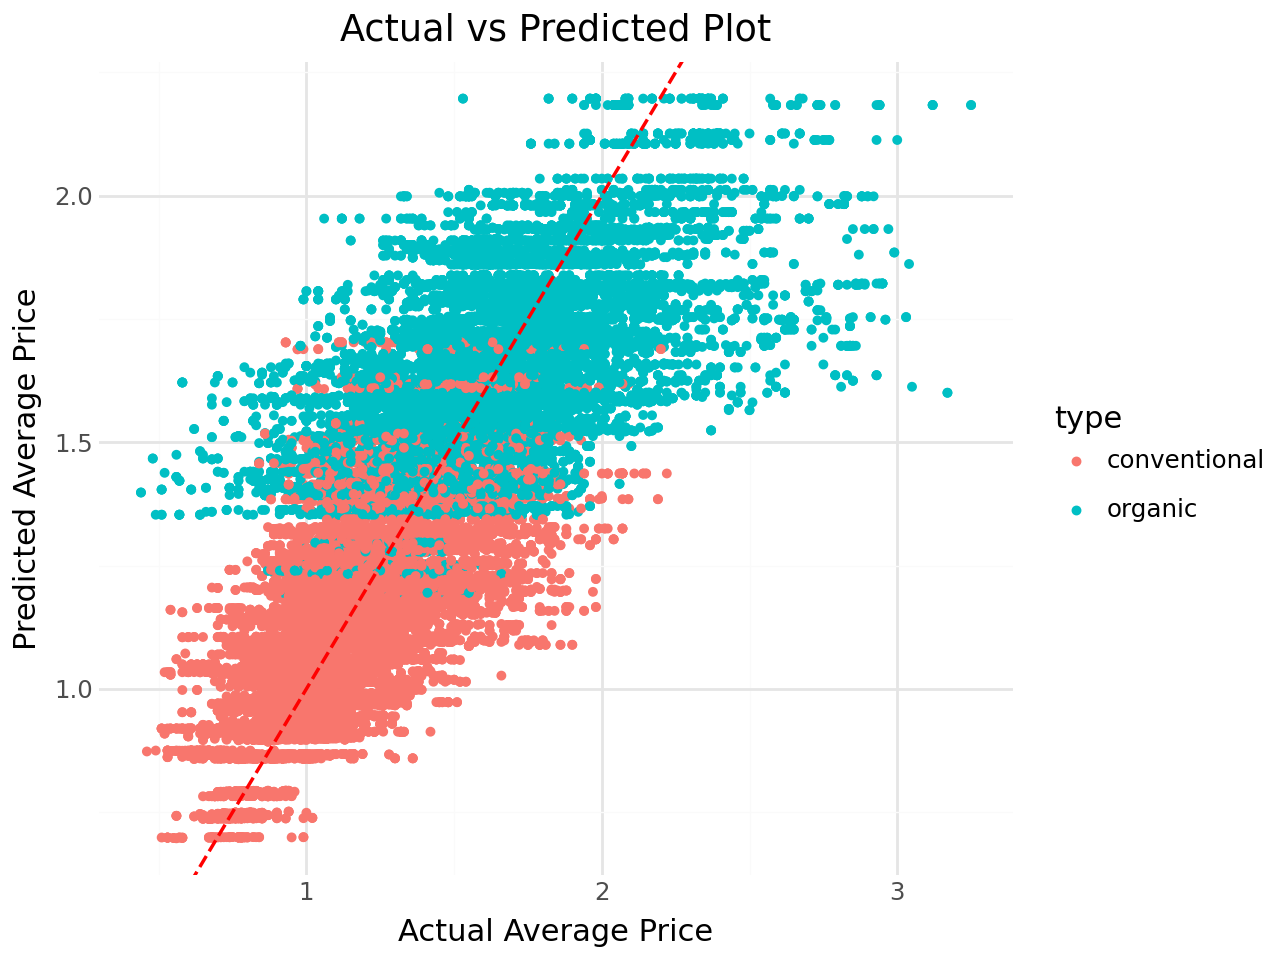

In [73]:
(ggplot(x_test, aes("average_price", "prediction", color = 'type'))
+ geom_point(size=1)
             #color="steelblue", alpha=0.5)
+ geom_abline(color="red", linetype="--", size=0.7)
+ theme_minimal()
+ labs(title="Actual vs Predicted Plot",
       x="Actual Average Price",
       y="Predicted Average Price"))

# Interpretation
The points are clustered tightly along the diagonal red line, meaning predicted prices are close to actual prices for both organic and conventional avocados. Organic avocados show slightly more spread at higher price points, suggesting the model is marginally less precise for expensive avocados, but overall the model performs well on unseen data.

In [74]:
# Evaluate on TEST data — compare against y_test (actual values)
r2_test   = r2_score(y_test, test_pred)
mse_test  = mean_squared_error(y_test, test_pred)
rmse_test = np.sqrt(mse_test)
mae_test  = mean_absolute_error(y_test, test_pred)

print(f"TEST R²   = {r2_test:.4f}  : model explains {r2_test*100:.1f}% of variation on new data")
print(f"TEST RMSE = {rmse_test:.2f}   : predictions off by ±{rmse_test:.2f} on average")
print(f"TEST MAE  = {mae_test:.2f}   : typical prediction error is {mae_test:.2f}")

TEST R²   = 0.5979  : model explains 59.8% of variation on new data
TEST RMSE = 0.25   : predictions off by ±0.25 on average
TEST MAE  = 0.19   : typical prediction error is 0.19


# Interpretation
The test R² closely matches the training R², confirming the model is not overfitting, it generalises well to new data. Predictions are off by about 23 cents on average (RMSE), which is reasonable given that avocado prices range from around 0.44 to 3.25 in this dataset.

### Residual Plot for Model Assumption

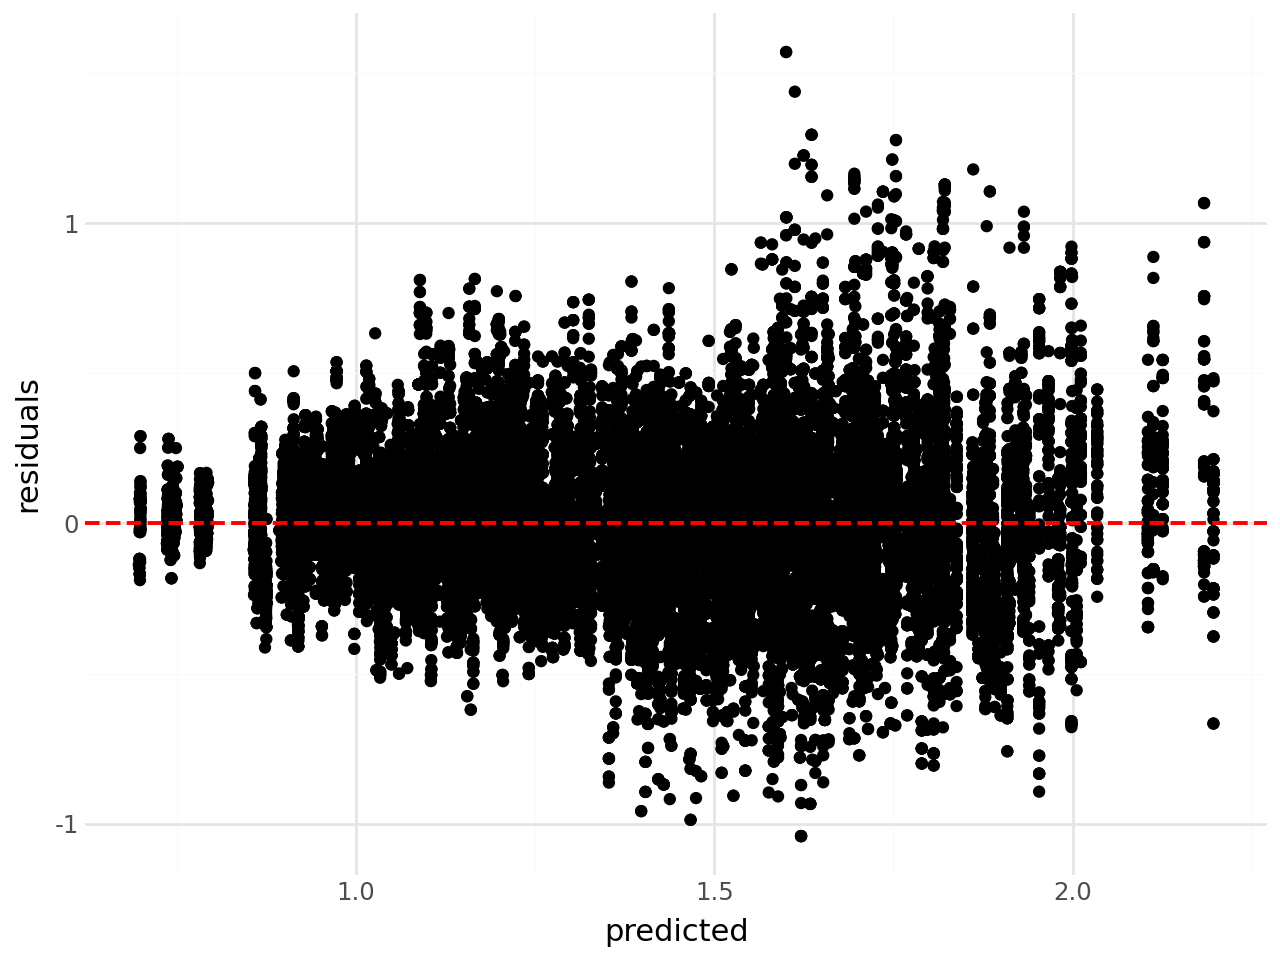

In [75]:
# The difference between the original dependent values and the predicted values
residual = y_test - test_pred
residual = pd.DataFrame({"residuals": residual, 'predicted' : test_pred})

# The residual plot
(ggplot(residual, aes("predicted", "residuals"))
+ geom_point()
+ geom_hline(aes(yintercept=0), color="red", linetype="--", size=0.8)
+ theme_minimal()
    
)

The residual plot shows the difference between actual and predicted prices across all predictions. Residuals scattered randomly above and below the red zero line with no clear pattern confirms that the linear regression assumptions are not violated, the model does not consistently overestimate or underestimate at any price range.

However, the spread of residuals widens slightly at higher predicted values. This is called heteroscedasticity — the model is less precise when predicting prices for expensive avocados (mostly organic, high-price markets) than for cheaper ones. This is consistent with the wider spread seen in the organic band of the actual vs predicted plot.
Overall the residuals are well-behaved, confirming the model is a valid linear regression and the predictions are unbiased.

#### Logistic Regression 
# Part 2: Avocado Type Classification
Objective: Classify avocados as Organic or Conventional. 
+ Option A: Logistic Regression - Encode target variable (Organic = 1, Conventional = 0) 
+ Train Logistic Regression model - Evaluate using accuracy, confusion matrix, precision, and recall

In [76]:
avocado.head()

,date,day,type,year,month,season,region,bag_type,plu_code,plu_volume,average_price,total_volume,total_bags,bag_volume
0,2015-01-04,04,conventional,2015,1,Winter,Albany,large bags,4046,2819.50,1.22,40873.28,9716.46,529.53
1,2015-01-04,04,conventional,2015,1,Winter,Albany,large bags,4225,28287.42,1.22,40873.28,9716.46,529.53
2,2015-01-04,04,conventional,2015,1,Winter,Albany,large bags,4770,49.90,1.22,40873.28,9716.46,529.53
3,2015-01-04,04,conventional,2015,1,Winter,Albany,small bags,4046,2819.50,1.22,40873.28,9716.46,9186.93
4,2015-01-04,04,conventional,2015,1,Winter,Albany,small bags,4225,28287.42,1.22,40873.28,9716.46,9186.93


In [77]:
# Encode the target
# organic = 1, conventional = 0
avocado['type_encoded'] = (avocado['type'] == 'organic').astype(int)


avocado[['type', 'type_encoded']].value_counts()

type          type_encoded
conventional  0               82134
organic       1               82107
Name: count, dtype: int64

In [78]:
# features (X) 
# target (y)
# X = numeric features only 
x_logit = avocado[['average_price', 'total_volume', 'total_bags', 'month', 'year']]
y_logit = avocado['type_encoded']

print('x shape:', x_logit.shape)
print('y_logit value counts:')
print(y_logit.value_counts())

x shape: (164241, 5)
y_logit value counts:
type_encoded
0    82134
1    82107
Name: count, dtype: int64


In [79]:
# Train/test split
from sklearn.model_selection import train_test_split

x_train_logit, x_test_logit, y_train_logit, y_test_logit = train_test_split(
    x_logit, y_logit, test_size=0.2, random_state=42)

print('Training set:', x_train_logit.shape)
print('Test set:    ', x_test_logit.shape)

Training set: (131392, 5)
Test set:     (32849, 5)


In [80]:
x_train_logit.head()

,average_price,total_volume,total_bags,month,year
121140,1.59,150790.27,72724.55,5,2017
90178,1.56,10289.97,10166.02,10,2016
83085,0.93,6290164.89,2158077.84,8,2016
149581,1.50,102658.15,81188.29,12,2017
46882,1.00,2233138.01,437811.32,12,2015


In [81]:
x_test_logit.head()

,average_price,total_volume,total_bags,month,year
116022,1.58,370816.51,48772.99,4,2017
96168,1.04,10510.27,8595.91,11,2016
45069,1.00,83963.95,25520.11,11,2015
30774,2.31,5078.46,479.05,8,2015
131758,1.74,13741.86,5820.33,8,2017


In [82]:
# Standardization to put all the value in the same scale
from sklearn.preprocessing import StandardScaler
#calling up the standard scaler
scaler = StandardScaler()

In [83]:
#fitting our data into the standard scaler
x_logit_standard_scaled = scaler.fit(x_train_logit)                        

x_logit_standard_scaled

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [84]:
# Transforming our data
x_train_logit_scaled = scaler.transform(x_train_logit)  

x_test_logit_scaled  = scaler.transform(x_test_logit)   

x_train_logit_scaled

array([[ 0.45638379, -0.20216042, -0.16900366, -0.33101027,  0.90902157],
       [ 0.38194048, -0.24255656, -0.23210366,  1.08344981, -0.15439972],
       [-1.18136905,  1.56301049,  1.93439929,  0.51766578, -0.15439972],
       ...,
       [ 1.25044577, -0.22479227, -0.19234605,  0.51766578,  0.90902157],
       [-0.48656482, -0.17958989, -0.13131681,  1.36634182,  0.90902157],
       [-0.31286376, 10.40147428, 12.44913618, -0.33101027,  0.90902157]])

In [85]:
# putting them in a dataframe

x_train_logit_scaled_df = pd.DataFrame(x_train_logit_scaled, columns=x_train_logit.columns)
x_test_logit_scaled_df  = pd.DataFrame(x_test_logit_scaled,  columns=x_test_logit.columns)

x_train_logit_scaled_df.head()

,average_price,total_volume,total_bags,month,year
0,0.456384,-0.202160,-0.169004,-0.331010,0.909022
1,0.381940,-0.242557,-0.232104,1.083450,-0.154400
2,-1.181369,1.563010,1.934399,0.517666,-0.154400
3,0.233054,-0.215999,-0.160467,1.649234,0.909022
4,-1.007668,0.396549,0.199243,1.649234,-1.217821


In [86]:
x_test_logit_scaled_df.head()

,average_price,total_volume,total_bags,month,year
0,0.431569,-0.138899,-0.193163,-0.613902,0.909022
1,-0.908410,-0.242493,-0.233687,1.366342,-0.154400
2,-1.007668,-0.221374,-0.216617,1.366342,-1.217821
3,2.243023,-0.244055,-0.241874,0.517666,-1.217821
4,0.828600,-0.241564,-0.236487,0.517666,0.909022


In [87]:
# Train the model
from sklearn.linear_model import LogisticRegression

type_model = LogisticRegression()

type_model.fit(x_train_logit_scaled_df, y_train_logit) #fit our model with the feature and target

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [88]:
type_model.intercept_

array([-8.37187895])

In [89]:
type_model.coef_

array([[  1.83905347, -68.08015173,  27.4198263 ,  -0.45973353,
         -0.35371202]])

In [90]:
#tidying it up
type_coef_df = pd.DataFrame(type_model.coef_.T, x_train_logit_scaled_df.columns, columns = ['coefficient'])
type_coef_df

,coefficient
average_price,1.839053
total_volume,-68.080152
total_bags,27.419826
month,-0.459734
year,-0.353712


The results above are in log odd
#### conventional : 0
#### organic : 1
+ As the price goes up, the Log odd for the avocado being organic increases
+ As the volume goes up, the Log odd for the avocado being organic decreases
+ As the total bags goes up, the Log odd for the avocado being organic increases
+ As the month progresses, the Log odd for the avocado being organic decreases
+ As the year progresses, the Log odd for the avocado being organic decreases

In [91]:
#transforming our coefficients into odds from log odd
import numpy as np
type_coef_df = pd.DataFrame(np.exp(type_model.coef_),  columns = x_train_logit_scaled_df.columns)
type_coef_df

,average_price,total_volume,total_bags,month,year
0,6.290581,2.711226e-30,8.096163e+11,0.631452,0.702077


### Interpretation
 greater than 1 (>1) means the chances of it being organic is higher

< 1 decreases the chance of it being organic

+ Average price (odds ratio = 6):avocados are 6 times more likely to be organic at higher price points.
+ Higher volume decreases the odds of being organic. Conventional avocados dominate market sales while organic supply is more limited.

###  Predicting on training data 

In [92]:
y_train_logit_pred = type_model.predict(x_train_logit_scaled_df)

In [93]:
from sklearn import metrics

In [94]:
print(metrics.classification_report(y_train_logit, y_train_logit_pred))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92     65631
           1       0.90      0.94      0.92     65761

    accuracy                           0.92    131392
   macro avg       0.92      0.92      0.92    131392
weighted avg       0.92      0.92      0.92    131392



# Interpretation
The model achieves 92% accuracy on training data. Precision of 90% means that when the model predicts organic, it is right 90% of the time. Recall of 94% means the model correctly identifies 94% of all actual organic avocados. These are strong results, showing the model has learned to reliably separate organic from conventional avocados.

#### Confusion Metrics

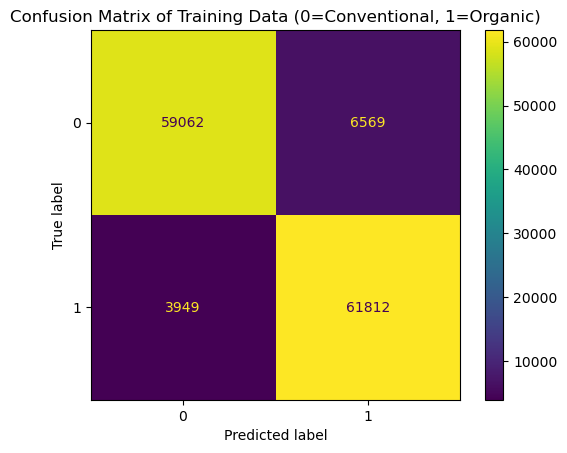

In [95]:
# Confusion matrix 
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_train_logit, y_train_logit_pred)
plt.title('Confusion Matrix of Training Data (0=Conventional, 1=Organic)')
plt.show()

+ True negatives : 59062
+ False positives: 6569
+ False Negatives: 3949
+ True Positives: 61812

From our prediction, 61812 got the prediction on our avocado being organic right 

Where it was actually conventional and the data was saying organic: 6569

Where the model was saying conventional while it was organic: 3949


#### Predicting on test data 

In [96]:
y_test_logit_pred = type_model.predict(x_test_logit_scaled_df)

print(metrics.classification_report(y_test_logit, y_test_logit_pred))

              precision    recall  f1-score   support

           0       0.93      0.90      0.92     16503
           1       0.90      0.94      0.92     16346

    accuracy                           0.92     32849
   macro avg       0.92      0.92      0.92     32849
weighted avg       0.92      0.92      0.92     32849



# Interpretation
The test accuracy of 92% matches the training accuracy, confirming the model generalises well and is not memorising the training data. Precision and recall remain consistent, meaning the model performs equally well on data it has never seen before.

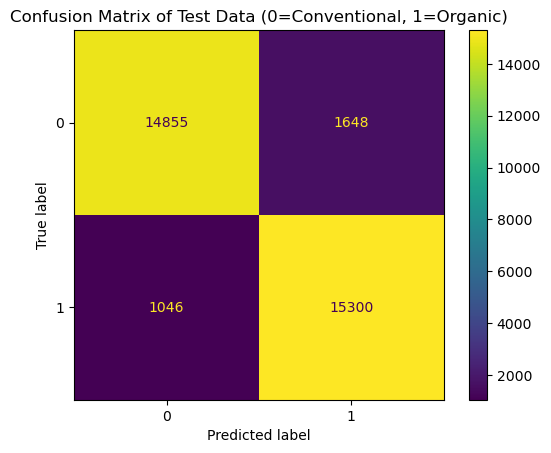

In [97]:
#Confusion matrix: test data
ConfusionMatrixDisplay.from_predictions(y_test_logit, y_test_logit_pred)
plt.title('Confusion Matrix of Test Data (0=Conventional, 1=Organic)')
plt.show()

+ True negatives : 14855
+ False positives: 1648
+ False Negatives: 1046
+ True Positives: 15300


In [4]:
# Conclusion

# FINAL INSIGHTS

# Key Drivers of Avocado Prices
The analysis shows that avocado prices are primarily influenced by a combination of product type, supply levels, location, and seasonlity.
- Type (Organic vs Conventional): Organic avocados consistently command higher prices due to premium demand and higher production costs.
Supply (Total Volume): Price is inversely related to supply: higher volumes generally lead to lower prices.
- Seasonality (Time of Year): Prices fluctuate across months and years, highlighting strong seasonal effects.
- Region: Location plays a critical role, with certain regions maintaining higher prices regardless of volume due to demand differences.
- Product Details (PLU Codes / Bag Types): Specific avocado sizes and packaging formats contribute to pricing variations that are not immediately visible in aggregated data.

# Model Development & Comparison
Four linear regression models were developed progressively to improve predictive performance:
- Model 1: Established a baseline using basic features but lacked the ability to capture complex relationships.
- Model 2: Introduced additional variables, improving accuracy but still limited in handling interactions.
- Model 3: Incorporated more refined features and structure, reducing error further.
- Model 4 (Final Model): Achieved the lowest error rates and highest R², making it the most reliable model.

Why Model 4 was selected:
Model 4 not only improved overall accuracy but successfully captured interaction effects, particularly how region and type jointly influence price. For example, even in high-supply regions, prices can remain high during peak demand periods — a pattern earlier models failed to capture.

# Classification Effectiveness (Organic vs Conventional)
A classification model was used to evaluate how well avocado type can be predicted based on market features.
- Overall Accuracy: High, with test performance closely matching training results, indicating good generalization and no overfitting.
- Performance Breakdown:
+ True Positives: 15,300 organic avocados correctly identified
+ True Negatives: 14,855 conventional avocados correctly identified
- Key Limitation – "Premium Pricing" Effect:The model produced 1,642 false positives, where conventional avocados were misclassified as organic.

Insight:
This misclassification reflects real-world market behavior rather than model weakness. In high-demand regions or peak seasons, conventional avocados can reach price levels similar to organic ones, making them statistically difficult to distinguish.

# Overall Conclusion
This project demonstrates that avocado pricing is not driven by a single factor but by the interaction of type, region, and timing.
- Model Selection: The final Linear Regression model (Model 4) proved to be the most effective, balancing interpretability with strong predictive performance.
- Data Structuring Impact: Transforming the dataset from a wide to long format significantly improved analysis by exposing hidden relationships between product categories and pricing.
- Key Insight: While organic avocados are generally more expensive, regional demand and seasonal effects can override this distinction, especially in premium markets.
- Business Implication: Pricing strategies should be region-specific rather than uniform, as local demand patterns have a stronger influence on price than product type alone